# Rocket Launch Scheduling (ILP)

This notebook models a rocket launch scheduling problem using Integer Linear Programming (ILP).

<a id="table-of-contents"></a>
## Table of Contents
- [Rocket Launch Scheduling (ILP)](#rocket-launch-scheduling-ilp)
  - [Data](#data)
  - [Decision variable](#decision-variable)
  - [Problem](#problem)
  - [Objective: maximize total priority score](#objective-maximize-total-priority-score)
  - [Constraints](#constraints)
  - [Solve](#solve)
  - [Extract results](#extract-results)
  - [Results](#results)
  - [Visualization Functions](#visualization-functions)
  - [Execute Visualizations](#execute-visualizations)


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib as mpl
import pulp as pl
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# Set a nice style
try:
    plt.style.use("ggplot")
except:
    pass

<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## Data

In [2]:
Rockets = ["Falcon9", "Starship", "Electron"]
Pads = ["Pad_A", "Pad_B"]
Periods = [1, 2, 3, 4]
PrepTime = {"Falcon9": 1, "Starship": 2, "Electron": 1}  # periods needed for prep/fuel
FuelCost = {"Falcon9": 50, "Starship": 100, "Electron": 20}  # fuel per launch
LaunchCost = {"Falcon9": 100, "Starship": 500, "Electron": 30}
Priority = {
    "Falcon9": 50,
    "Starship": 100,
    "Electron": 20,
}  # higher than launch cost to make scheduling attractive
MaxFuelPerPad = {"Pad_A": 200, "Pad_B": 150}  # total fuel limit per pad

<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## Decision variable

In [3]:
# x[r][p][t] = 1 if rocket r launches from pad p at period t
x = pl.LpVariable.dicts("Launch", (Rockets, Pads, Periods), cat="Binary")

<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## Problem

In [4]:
prob = pl.LpProblem("Rocket_Launch", pl.LpMaximize)

<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## Objective: maximize total priority score

In [5]:
prob += pl.lpSum(
    [Priority[r] * x[r][p][t] for r in Rockets for p in Pads for t in Periods]
)

<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## Constraints

In [6]:
# 1. Each rocket launches at most once
for r in Rockets:
    prob += pl.lpSum([x[r][p][t] for p in Pads for t in Periods]) <= 1

# 2. Pad cannot host overlapping rockets (prep/fuel)
for p in Pads:
    for t in Periods:
        prob += (
            pl.lpSum(
                [
                    x[r][p][tp]
                    for r in Rockets
                    for tp in range(max(1, t - PrepTime[r] + 1), t + 1)
                    if tp in Periods
                ]
            )
            <= 1
        )

# 3. Fuel limit per pad
for p in Pads:
    prob += (
        pl.lpSum([FuelCost[r] * x[r][p][t] for r in Rockets for t in Periods])
        <= MaxFuelPerPad[p]
    )  # Fixed: Use MaxFuelPerPad[p]

<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## Solve

In [7]:
prob.solve(pl.PULP_CBC_CMD(msg=1))

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/jules/.pyenv/versions/3.12.13/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/7c6b5151578d4c8d8e1a903a2021bdd4-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /tmp/7c6b5151578d4c8d8e1a903a2021bdd4-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 18 COLUMNS
At line 169 RHS
At line 183 BOUNDS
At line 208 ENDATA
Problem MODEL has 13 rows, 24 columns and 78 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 170 - 0.00 seconds
Cgl0008I 3 inequality constraints converted to equality constraints
Cgl0005I 3 SOS with 27 members
Cgl0004I processed model has 13 rows, 27 columns (27 integer (27 of which binary)) and 81 elements
Cutoff increment increased from 1e-05 to 9.9999
Cbc0038I Initial state - 0 integers unsatisfied sum - 0
Cbc0038I Solution foun

1

<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## Extract results

In [8]:
Assignments = {}
TotalCost = 0
TotalPriority = 0
FuelUsedPerPad = {p: 0 for p in Pads}

for r in Rockets:
    for p in Pads:
        for t in Periods:
            if pl.value(x[r][p][t]) == 1:
                Assignments[r] = (p, t)
                TotalCost += LaunchCost[r]
                TotalPriority += Priority[r]
                FuelUsedPerPad[p] += FuelCost[r]

<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## Results

In [9]:
from IPython.display import display, HTML


# Helper to style dataframes
def style_dataframe(
    df, caption, cmap="Blues", header_color="#f4f4f4", header_text="#333"
):
    display(Markdown(f"### {caption}"))
    return (
        df.style.background_gradient(cmap=cmap)
        .set_table_attributes(f'aria-label="{caption}"')
        .set_table_styles(
            [
                {
                    "selector": "th",
                    "props": [
                        ("background-color", header_color),
                        ("color", header_text),
                        ("font-weight", "bold"),
                        ("text-align", "center"),
                    ],
                },
                {
                    "selector": "td",
                    "props": [("text-align", "center"), ("padding", "8px")],
                },
                {
                    "selector": "tr:hover",
                    "props": [("filter", "brightness(0.95)")],
                },
                {
                    "selector": "caption",
                    "props": [
                        ("font-size", "16px"),
                        ("font-weight", "bold"),
                        ("margin-bottom", "10px"),
                        ("color", "#333"),
                    ],
                },
            ]
        )
        .hide(axis="index")
        .format(precision=1)
    )


display(Markdown(f"**Total Launch Cost:** {TotalCost}"))
display(Markdown(f"**Total Priority Score:** {TotalPriority}"))

assignment_list = []
for r, (p, t) in Assignments.items():
    assignment_list.append({"Rocket": r, "Pad": p, "Period": t})
if assignment_list:
    df_assignments = pd.DataFrame(assignment_list)
    display(style_dataframe(df_assignments, "🚀 Assignments", cmap="GnBu"))
else:
    display(Markdown("### 🚀 Assignments\n*No assignments found.*"))

fuel_list = []
for p, fuel in FuelUsedPerPad.items():
    fuel_list.append({"Pad": p, "Fuel Used": fuel})
if fuel_list:
    df_fuel = pd.DataFrame(fuel_list)
    display(style_dataframe(df_fuel, "⛽ Fuel Used Per Pad", cmap="Oranges"))
else:
    display(Markdown("### ⛽ Fuel Used Per Pad\n*No fuel used.*"))

**Total Launch Cost:** 630

**Total Priority Score:** 170

### 🚀 Assignments

Rocket,Pad,Period
Falcon9,Pad_B,3
Starship,Pad_B,1
Electron,Pad_A,2


### ⛽ Fuel Used Per Pad

Pad,Fuel Used
Pad_A,20
Pad_B,150


<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## Visualization Functions

In [10]:
def visualize_schedule(assignments, rockets, pads, periods, prep_time):
    # Create a color map for rockets
    cmap = mpl.colormaps["tab10"]
    rocket_colors = {rocket: cmap(i) for i, rocket in enumerate(rockets)}

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(12, 6))

    # Create y-axis ticks and labels
    y_ticks = []
    y_labels = []

    # Plot each pad
    for pad_idx, pad in enumerate(pads):
        y_pos = pad_idx * 2
        y_ticks.append(y_pos)
        y_labels.append(f"Pad {pad[-1]}")

        # Draw pad line
        ax.axhline(y=y_pos, color="gray", linestyle="-", alpha=0.3)

        # Plot scheduled launches
        for rocket, (assigned_pad, start_time) in assignments.items():
            if assigned_pad == pad:
                end_time = start_time + prep_time[rocket]
                ax.barh(
                    y_pos,
                    width=prep_time[rocket],
                    left=start_time - 0.5,
                    height=1.5,
                    color=rocket_colors[rocket],
                    edgecolor="white",
                    linewidth=1,
                    alpha=0.9,
                    label=rocket,
                )
                # Add rocket name to the bar
                ax.text(
                    start_time + prep_time[rocket] / 2 - 0.5,
                    y_pos,
                    rocket,
                    ha="center",
                    va="center",
                    color="white",
                    fontweight="bold",
                    fontsize=10,
                )

    # Set y-ticks and labels
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    ax.set_ylim(-1, len(pads) * 2 - 1)

    # Set x-ticks and labels
    ax.set_xticks(range(1, max(periods) + 2))
    ax.set_xlabel("Time Period", fontsize=14)
    ax.set_title("Rocket Launch Schedule", fontsize=16)

    # Add legend (without duplicates)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(
        by_label.values(),
        by_label.keys(),
        title="Rocket Types",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        frameon=True,
        shadow=True,
    )

    # Add grid
    ax.grid(True, linestyle="--", alpha=0.5, axis="x")

    plt.tight_layout()
    plt.show()


def visualize_fuel_usage(fuel_used_per_pad, max_fuel_per_pad):
    fig, ax = plt.subplots(figsize=(8, 6))
    pads = list(fuel_used_per_pad.keys())
    fuel_used = [fuel_used_per_pad[p] for p in pads]
    max_fuel = [max_fuel_per_pad[p] for p in pads]

    x = np.arange(len(pads))
    width = 0.35

    ax.bar(
        x - width / 2,
        fuel_used,
        width,
        label="Fuel Used",
        color="skyblue",
        edgecolor="black",
        alpha=0.8,
    )
    ax.bar(
        x + width / 2,
        max_fuel,
        width,
        label="Max Fuel Capacity",
        color="lightcoral",
        edgecolor="black",
        alpha=0.8,
    )

    ax.set_xlabel("Pads", fontsize=14)
    ax.set_ylabel("Fuel Units", fontsize=14)
    ax.set_title("Fuel Usage vs. Capacity per Pad", fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels([p[-1] for p in pads])
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid(True, linestyle="--", alpha=0.5, axis="y")

    # Add value labels on top of bars
    for i, v in enumerate(fuel_used):
        ax.text(i - width / 2, v + 5, str(v), ha="center", va="bottom")
    for i, v in enumerate(max_fuel):
        ax.text(i + width / 2, v + 5, str(v), ha="center", va="bottom")

    plt.tight_layout()
    plt.show()


def visualize_cost_breakdown(assignments, launch_cost):
    if not assignments:
        display(Markdown("*No cost breakdown to visualize (no assignments).*"))
        return

    rockets = [r for r in assignments.keys()]
    costs = [launch_cost[r] for r in rockets]

    # Explode the largest slice
    explode = [0.05 if c == max(costs) else 0 for c in costs]

    # 🎨 UX Improvement: Accessible text alternative for Pie Chart
    display(Markdown("### 📊 Launch Cost Breakdown Data"))
    html_table = "<table aria-label=\"Launch Cost Breakdown\">\n"
    html_table += "  <thead>\n"
    html_table += "    <tr><th scope=\"col\">Rocket</th><th scope=\"col\">Cost</th></tr>\n"
    html_table += "  </thead>\n"
    html_table += "  <tbody>\n"
    for r, c in zip(rockets, costs):
        html_table += f"    <tr><th scope=\"row\">{r}</th><td>{c}</td></tr>\n"
    html_table += "  </tbody>\n</table>"
    display(HTML(html_table))

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(
        costs,
        labels=rockets,
        autopct="%1.1f%%",
        startangle=90,
        colors=[mpl.colormaps["tab10"](i) for i in range(len(rockets))],
        explode=explode,
        shadow=True,
        wedgeprops={"alpha": 0.8},
    )
    ax.set_title("Launch Cost Breakdown by Rocket", fontsize=16)
    plt.tight_layout()
    plt.show()


def visualize_priority_scores(assignments, priority):
    if not assignments:
        display(Markdown("*No priority scores to visualize (no assignments).*"))
        return

    rockets = [r for r in assignments.keys()]
    scores = [priority[r] for r in rockets]

    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.bar(rockets, scores, color="seagreen", edgecolor="black", alpha=0.8)

    ax.set_xlabel("Rockets", fontsize=14)
    ax.set_ylabel("Priority Score", fontsize=14)
    ax.set_title("Priority Scores of Scheduled Rockets", fontsize=16)
    ax.grid(True, linestyle="--", alpha=0.5, axis="y")

    # Add value labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 2,
            str(int(yval)),
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()


<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>

## Execute Visualizations

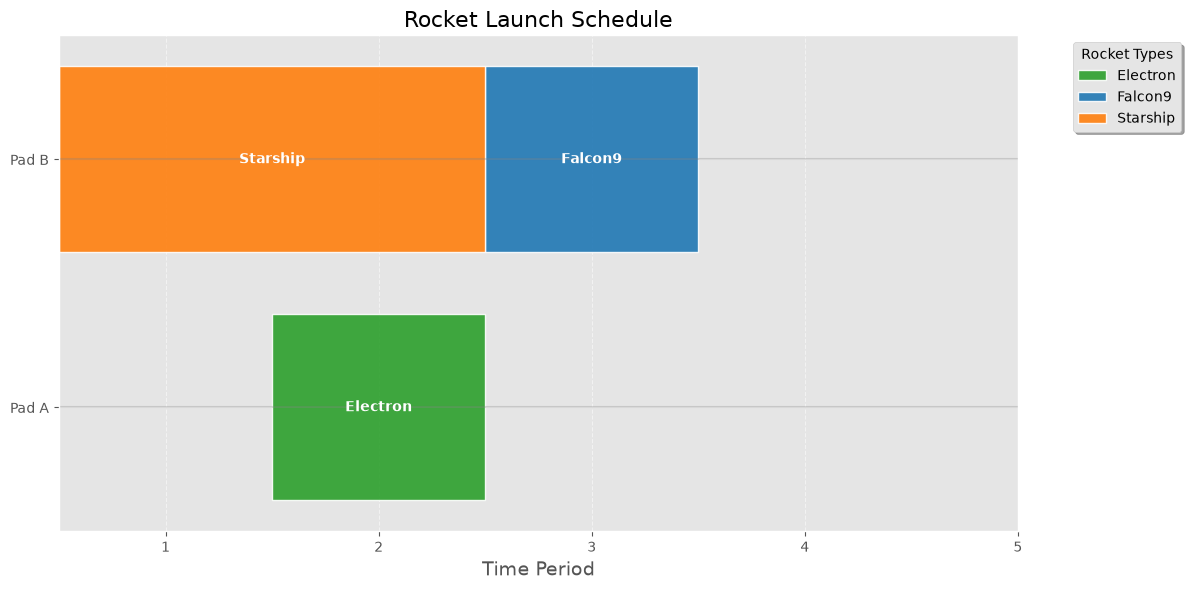

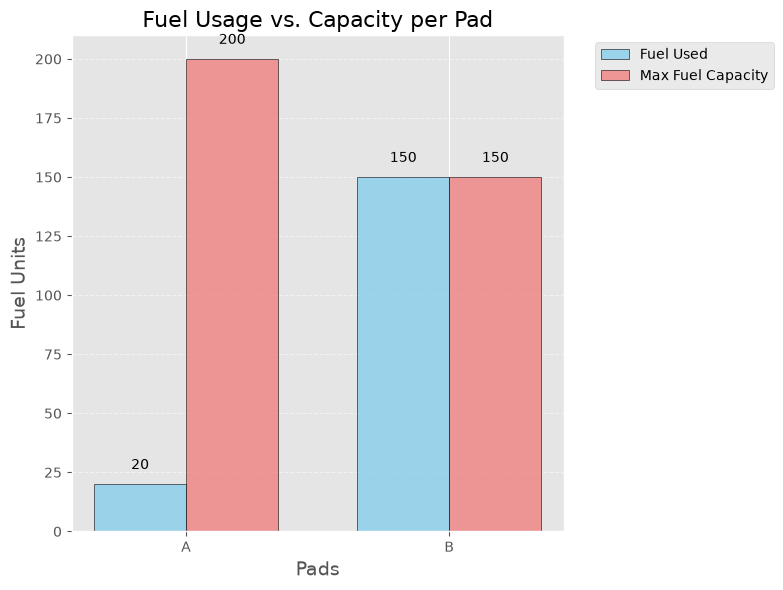

### 📊 Launch Cost Breakdown Data

Rocket,Cost
Falcon9,100
Starship,500
Electron,30


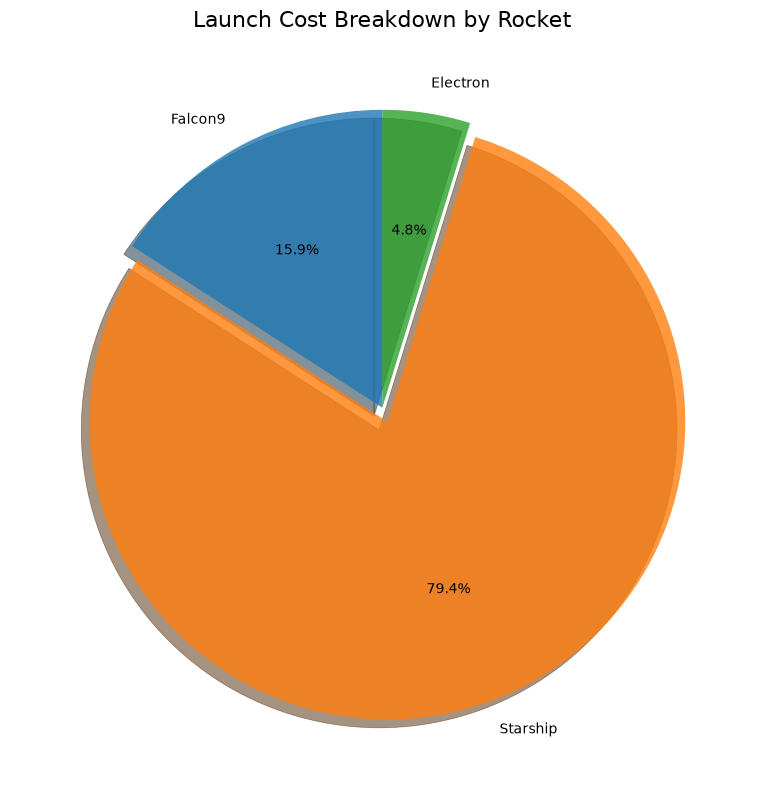

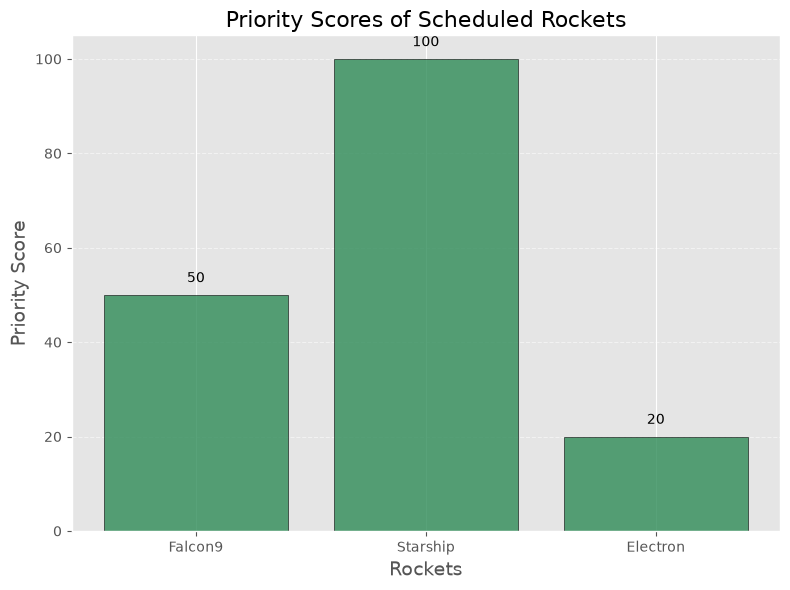

In [11]:
if "Assignments" in locals() and Assignments:
    visualize_schedule(Assignments, Rockets, Pads, Periods, PrepTime)
    visualize_fuel_usage(FuelUsedPerPad, MaxFuelPerPad)
    visualize_cost_breakdown(Assignments, LaunchCost)
    visualize_priority_scores(Assignments, Priority)
else:
    display(Markdown("*No assignments found. Please run the optimization first.*"))

<div align="right"><a href="#table-of-contents">⬆️ Back to Top</a></div>